# Bead intensity & count per FOV — epi vs. disk (`BC555_sample_05`)

Continuation of the disk hot-pixel investigation
(`test_hot_pixel_detection.ipynb`): visual inspection there suggested disk's
beads look dimmer and sparser than epi's. This notebook measures that
directly across **every FOV** of both experiments:

1. **Peak intensity** of detected beads in the fiducial frame.
2. **Number of detected beads per FOV.**

**Fiducial frame**: raw camera frame 0 of the `cells` round, confirmed (not
assumed) here via `MERci.acquisition.alignment.bead_frame_indices` against
each dataset's own real frame table (`metadata/frame-table-*.csv`) — 488 nm
at z=0 for both epi and disk.

**Hot-pixel correction**: `remove_hot_pixels` (already validated, used by
this repo's other bead-analysis notebooks) is applied to every frame before
detection. Disk additionally has two *confirmed* fixed camera defects
(`test_hot_pixel_detection.ipynb`: `(1214,1008)`, `(849,364)`) that sit right
at/under `remove_hot_pixels`' default `ratio=5.0` threshold and so are NOT
reliably caught every single frame by the generic detector — those two exact
coordinates are unconditionally replaced by their own local median in every
disk frame, in addition to the generic correction, so they can't leak into
the "bead" count/intensity as camera artifacts.

**Detection**: `MERci.analysis.spot_localization.detect_beads_2d` (this
repo's existing bead/fiducial-detection primitive — also the one
`fast_spot_quantification.ipynb` reuses for real hybridization foci).
`min_dist_px` is shared; `thresh_sigma` is tuned **per dataset** by eye
against a diagnostic overlay (Section 3) rather than shared, because epi's
fiducial frame is an extremely dense, near-saturated field of puncta (frame
mean ~18,000, 16-bit-saturating in places) while disk's is sparse and dim
(frame mean ~104, mostly sensor background) — the same global-percentile
threshold that works for one regime is either swamped by disk's sensor noise
or, for epi, still only recovers epi's biggest/brightest clumps regardless of
how it's tuned (checked at several `thresh_sigma` values — even the most
permissive one visually misses the large majority of epi's individual
puncta, which sit closer together than any dense field an isolated-local-
maximum detector can fully resolve).

**Saturated-plateau fix**: an initial full-population run found `detect_beads_2d`'s
`maximum_filter(blurred) == blurred` local-maximum test degenerates on flat
16-bit-saturated regions -- every pixel in a saturated plateau is trivially
its own "local maximum" (a tie), so one real saturated blob gets counted as
hundreds/thousands of separate "beads" all reading exactly 65535. Confirmed
on real data: 78.9% of every epi detection across the full population sat at
the exact 16-bit ceiling, and the single worst FOV's absurd 141,928-bead
count was 100% saturated-plateau artifact. Fixed by dropping any candidate
whose (hot-pixel-corrected) intensity is `>= 65535` before it ever reaches
the count/intensity tables below -- applied uniformly to both datasets
(a no-op for disk, which never saturates).

**Important caveats — read before interpreting the count panel**: because
the threshold is tuned per dataset, **the two "beads per FOV" distributions
are not on a shared absolute detection-efficiency scale** — disk's count is
a reasonably complete census of its (sparse) real puncta, while epi's is a
systematic *undercount* of its true bead density in two independent ways:
(1) it recovers only the subset of puncta that emerge as isolated local
maxima at `min_dist_px=7` separation, in a field where real beads often sit
closer together than that, and (2) every saturated plateau -- itself
evidence of a dense/bright cluster of real beads -- is now dropped entirely
rather than double(or 1000x)-counted, so epi's true bead density in its
brightest regions is undercounted by an unknown, unrecoverable amount (the
clipped pixel values there don't distinguish one very bright bead from many
overlapping ones). The **peak-intensity distribution also inherits the
saturation caveat**: `65535` is a hard sensor ceiling, not a true intensity,
so epi's real intensity distribution extends further right than what's
plotted -- both figures below are legitimate for comparing what the detector
*can* resolve, not for an absolute, saturation-corrected measurement in
either dataset.

Scans **every FOV** of both experiments (476 epi + 603 disk), not a
subsample, since a comparison-quality distribution needs the full
population.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/tests/stitching/test_hot_pixel_detection.ipynb.
MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.alignment  import remove_hot_pixels, bead_frame_indices
from MERci.acquisition.configs    import find_frame_table_for_hal_config
from MERci.analysis.spot_localization import detect_beads_2d
from MERci.progress_display       import ProgressReporter

NOTEBOOK_NAME = "test_bead_intensity_and_count_epi_vs_disk"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
BASE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05")
IMAGE_SUFFIX = ".zarr"

# (label, experiment dir, detect_beads_2d thresh_sigma, extra known fixed hot-pixel
# (row, col) locations to force-correct beyond remove_hot_pixels' own generic
# flagging -- see markdown above. thresh_sigma tuned by eye per dataset (Section 3).
DATASETS = [
    ("epi",  BASE_DIR / "epi",  5.0,  []),
    ("disk", BASE_DIR / "disk", 10.0, [(1214, 1008), (849, 364)]),
]
MIN_DIST_PX = 7   # shared -- minimum centre-to-centre separation (pixels) for detect_beads_2d

FORCE_RECOMPUTE = False

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

DATASET_COLORS = {"epi": "tab:blue", "disk": "tab:orange"}

for label, exp_dir, thresh_sigma, hot_px in DATASETS:
    print(f"{label:5s}: {exp_dir}  thresh_sigma={thresh_sigma}  extra_hot_px={hot_px}")

epi  : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi  thresh_sigma=5.0  extra_hot_px=[]
disk : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk  thresh_sigma=10.0  extra_hot_px=[(1214, 1008), (849, 364)]


## 3 — Resolve dataset geometry, confirm the fiducial frame index

`bead_frame_indices` is run against each dataset's own real frame table
(not assumed) to confirm frame 0 really is the fiducial (488 nm, z=0)
frame for both.

In [3]:
def resolve_dataset(dataset_label, dataset_dir):
    sample_name, imaging_dir = resolve_sample_identity(dataset_dir / "MERci")
    positions_tag = positions_file_tag(sample_name, imaging_dir)
    info = load_experiment_info(dataset_dir / "metadata" / "experiment_info.yaml")

    config = ExperimentConfig(
        data_dir       = dataset_dir / "data",
        metadata_dir   = dataset_dir / "metadata",
        analysis_dir   = dataset_dir / "analysis",
        settings_dir   = dataset_dir / "settings",
        round_info_csv = dataset_dir / "metadata" / "round_info.csv",
        positions_txt  = dataset_dir / "positions" / f"positions_{positions_tag}.txt",
        image_suffix   = IMAGE_SUFFIX,
        microscope     = info.microscope,
    )
    meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                    image_suffix=config.image_suffix)
    cells_round_id = next(rid for rid in meta.valid_round_ids()
                           if meta.series_for_round(rid)[0].imaging_type.strip().lower() == "cells")
    series = meta.series_for_round(cells_round_id)[0]

    # Confirm the fiducial frame index against this dataset's own real frame table.
    hal_path = config.settings_dir / series.hal_config
    ft_path  = find_frame_table_for_hal_config(hal_path, config.metadata_dir)
    frame_table = pd.read_csv(ft_path)
    fiducial_frame_index = bead_frame_indices(frame_table)[0]

    all_fovs = sorted(meta.fovs)
    cache_dir = config.analysis_dir / "cache" / NOTEBOOK_NAME
    cache_dir.mkdir(parents=True, exist_ok=True)

    print(f"[{dataset_label}] microscope={info.microscope}  cells_round={cells_round_id}  "
          f"n_fovs={len(all_fovs)}  fiducial_frame_index={fiducial_frame_index}")
    return {
        "sample_name": sample_name, "config": config, "series": series,
        "all_fovs": all_fovs, "fiducial_frame_index": fiducial_frame_index,
        "cache_dir": cache_dir,
    }


DATASET_GEO = {label: resolve_dataset(label, exp_dir) for label, exp_dir, _, _ in DATASETS}

[epi] microscope=MF3  cells_round=1  n_fovs=476  fiducial_frame_index=0


[disk] microscope=ST2  cells_round=1  n_fovs=603  fiducial_frame_index=0


## 4 — Per-FOV bead detection

For every FOV: load the fiducial frame, hot-pixel-correct it, run
`detect_beads_2d`, and record every detected bead's `(fov, row, col,
intensity)` — `intensity` is the corrected frame's raw pixel value at the
detected peak. `n_beads` per FOV is just the count of rows per FOV in this
table. Cached per dataset under `analysis/cache/{NOTEBOOK_NAME}/` (real
per-experiment cache, ~1s/FOV read dominates runtime for a full-population
scan).

In [4]:
def correct_frame(frame, extra_hot_px):
    corrected = remove_hot_pixels(frame.astype(np.float64))
    for (y, x) in extra_hot_px:
        win = corrected[y - 3:y + 4, x - 3:x + 4]
        local_med = np.median(np.delete(win.ravel(), win.size // 2))
        corrected[y, x] = local_med
    return corrected


# detect_beads_2d's local-maximum test (maximum_filter(x) == x) degenerates on
# flat 16-bit-saturated plateaus -- every pixel in a saturated blob ties for
# "local maximum", so one real over-bright region gets counted as hundreds or
# thousands of spurious "beads" all reading exactly the sensor ceiling. Any
# candidate sitting at that ceiling isn't a real per-bead intensity measurement
# either way (it's clipped), so it's dropped before it reaches the count/
# intensity tables. See the saturated-plateau-fix markdown above for the real
# numbers this was confirmed against.
SATURATION_CEILING = 65535.0


def scan_dataset(dataset_label, dataset_dir, thresh_sigma, extra_hot_px):
    geo = DATASET_GEO[dataset_label]
    config, series = geo["config"], geo["series"]
    beads_csv = geo["cache_dir"] / "beads.csv"

    if beads_csv.exists() and not FORCE_RECOMPUTE:
        beads_df = pd.read_csv(beads_csv)
        print(f"[{dataset_label}] loaded cached: {beads_csv}  ({len(beads_df)} beads, "
              f"{beads_df['fov'].nunique()} FOVs)")
        return beads_df

    rows = []
    n_candidates_total = 0
    n_saturated_dropped = 0
    reporter = ProgressReporter(total=len(geo["all_fovs"]), label=f"[{dataset_label}] scanning FOVs")
    for fov_id in reporter.wrap(geo["all_fovs"]):
        path = series.resolve_path(fov_id, config.image_suffix)
        frame = read_image_frames(path, [geo["fiducial_frame_index"]],
                                   frame_width=config.frame_width, frame_height=config.frame_height)[0]
        corrected = correct_frame(frame, extra_hot_px)
        candidates = detect_beads_2d(corrected, min_dist_px=MIN_DIST_PX, thresh_sigma=thresh_sigma)
        n_candidates_total += len(candidates)
        for (y, x) in candidates:
            intensity = float(corrected[y, x])
            if intensity >= SATURATION_CEILING:
                n_saturated_dropped += 1
                continue
            rows.append({"fov": fov_id, "y": int(y), "x": int(x), "intensity": intensity})

    beads_df = pd.DataFrame(rows)
    beads_df.to_csv(beads_csv, index=False)
    sat_frac = n_saturated_dropped / n_candidates_total if n_candidates_total else 0.0
    print(f"[{dataset_label}] saved: {beads_csv}  ({len(beads_df)} beads kept, "
          f"{n_saturated_dropped} saturated-plateau candidates dropped [{sat_frac:.1%}], "
          f"{len(geo['all_fovs'])} FOVs)")
    return beads_df


BEADS = {}
COUNTS = {}
for label, exp_dir, thresh_sigma, hot_px in DATASETS:
    beads_df = scan_dataset(label, exp_dir, thresh_sigma, hot_px)
    BEADS[label] = beads_df
    all_fovs = DATASET_GEO[label]["all_fovs"]
    n_per_fov = beads_df.groupby("fov").size().reindex(all_fovs, fill_value=0)
    COUNTS[label] = n_per_fov
    print(f"{label:5s}: {len(beads_df)} beads total, {len(all_fovs)} FOVs, "
          f"mean {n_per_fov.mean():.1f} beads/FOV (range {n_per_fov.min()}-{n_per_fov.max()})")

[epi] scanning FOVs: [------------------------] 1/476 (  0.2%)  elapsed 1s  ETA 11m 18s          

[epi] scanning FOVs: [------------------------] 2/476 (  0.4%)  elapsed 3s  ETA 10m 13s          

[epi] scanning FOVs: [------------------------] 3/476 (  0.6%)  elapsed 4s  ETA 9m 40s          

[epi] scanning FOVs: [------------------------] 4/476 (  0.8%)  elapsed 5s  ETA 9m 36s          

[epi] scanning FOVs: [------------------------] 5/476 (  1.1%)  elapsed 6s  ETA 9m 22s          

...

[disk] scanning FOVs: [#######################-] 601/603 ( 99.7%)  elapsed 16m 11s  ETA 3s          

[disk] scanning FOVs: [#######################-] 602/603 ( 99.8%)  elapsed 16m 12s  ETA 2s          

[disk] scanning FOVs: [########################] 603/603 (100.0%)  elapsed 16m 14s  ETA 0s          

[disk] scanning FOVs: [########################] 603/603 (100.0%)  elapsed 16m 14s  ETA 0s          


[disk] saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_intensity_and_count_epi_vs_disk/beads.csv  (41982 beads kept, 0 saturated-plateau candidates dropped [0.0%], 603 FOVs)
disk : 41982 beads total, 603 FOVs, mean 69.6 beads/FOV (range 3-469)


## 5 — Comparison figures

Two figures, each 1x2 subplots (left: peak-intensity distribution, right:
per-FOV bead-count distribution), epi vs. disk overlaid as line plots
(density-normalized histograms — `np.histogram` + line through bin centers,
not bars). Figure 1 uses linearly-spaced bins; Figure 2 uses
log-spaced bins on the same two quantities. Saved to this repo's own
`cache/` (gitignored working output), matching `test_stitching.ipynb`'s own
convention for cross-experiment comparison figures — these are outputs
about *both* experiments together, not either one's own tree.

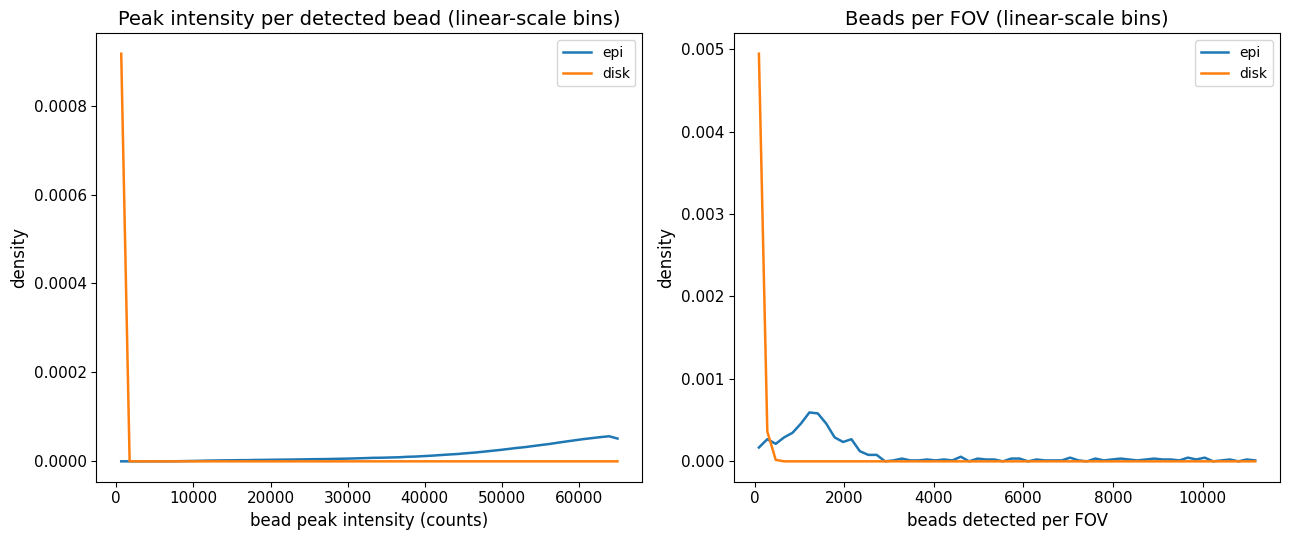

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_bead_intensity_and_count_epi_vs_disk/test_bead_intensity_and_count_epi_vs_disk.linear_bins.png


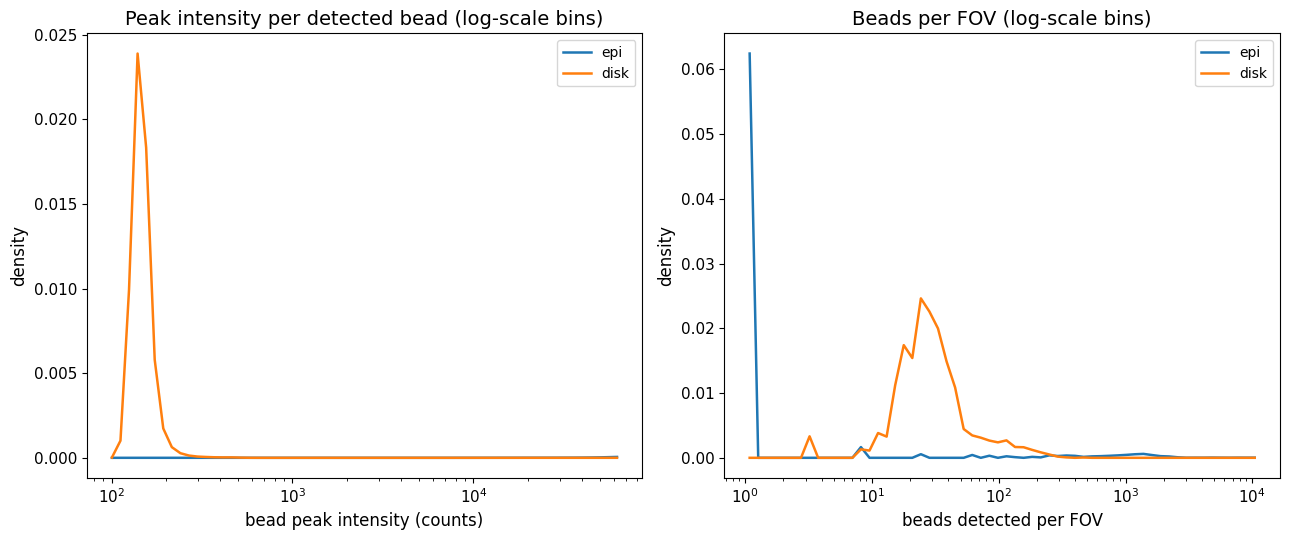

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_bead_intensity_and_count_epi_vs_disk/test_bead_intensity_and_count_epi_vs_disk.log_bins.png


In [5]:
COMPARISON_DIR = MERCI_DIR / "cache" / NOTEBOOK_NAME
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)


def plot_overlaid_hist(ax, values_by_label, bins, xlabel, title):
    for label, values in values_by_label.items():
        counts, edges = np.histogram(values, bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centers, counts, "-", lw=1.8, color=DATASET_COLORS[label], label=label)
    ax.set_xlabel(xlabel, fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("density", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(title, fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)


def build_figure(scale, n_bins=60):
    intensity_by_label = {label: BEADS[label]["intensity"].values for label, *_ in DATASETS}
    count_by_label      = {label: COUNTS[label].values.astype(float) for label, *_ in DATASETS}

    all_intensity = np.concatenate(list(intensity_by_label.values()))
    all_counts    = np.concatenate(list(count_by_label.values()))

    if scale == "linear":
        intensity_bins = np.linspace(all_intensity.min(), all_intensity.max(), n_bins + 1)
        count_min = max(all_counts.min(), 0)
        count_bins = np.linspace(count_min, all_counts.max(), n_bins + 1)
    else:
        intensity_bins = np.logspace(np.log10(max(all_intensity.min(), 1)),
                                      np.log10(all_intensity.max()), n_bins + 1)
        # per-FOV counts can be 0, which log-bins can't represent -- floor at 1
        # (a FOV with 0 detected beads still appears, just folded into the first bin).
        count_bins = np.logspace(np.log10(1), np.log10(max(all_counts.max(), 1)), n_bins + 1)
        count_by_label = {label: np.clip(v, 1, None) for label, v in count_by_label.items()}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    plot_overlaid_hist(axes[0], intensity_by_label, intensity_bins,
                        "bead peak intensity (counts)",
                        f"Peak intensity per detected bead ({scale}-scale bins)")
    plot_overlaid_hist(axes[1], count_by_label, count_bins,
                        "beads detected per FOV",
                        f"Beads per FOV ({scale}-scale bins)")
    if scale == "log":
        axes[0].set_xscale("log")
        axes[1].set_xscale("log")
    fig.tight_layout()
    out_path = COMPARISON_DIR / f"{NOTEBOOK_NAME}.{scale}_bins.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")


build_figure("linear")
build_figure("log")

## 6 — Summary stats

In [6]:
summary_rows = []
for label, *_ in DATASETS:
    intens = BEADS[label]["intensity"]
    counts = COUNTS[label]
    summary_rows.append({
        "dataset": label,
        "n_fovs": len(counts),
        "n_beads_total": len(intens),
        "intensity_mean": intens.mean(), "intensity_median": intens.median(),
        "intensity_std": intens.std(),
        "beads_per_fov_mean": counts.mean(), "beads_per_fov_median": counts.median(),
        "beads_per_fov_std": counts.std(),
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.round(2).to_string(index=False))

dataset  n_fovs  n_beads_total  intensity_mean  intensity_median  intensity_std  beads_per_fov_mean  beads_per_fov_median  beads_per_fov_std
    epi     476        1065834        51734.15           55140.0       11905.34             2239.15                1410.0            2438.54
   disk     603          41982          152.05             146.0          48.39               69.62                  39.0              66.75
